# 05 — Predictive Modelling

Classify binary depression from inflammatory markers. Compare biomarker-only vs full-feature models, assess feature importance, and test per-symptom predictability.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
PROCESSED = Path('../data/processed')
FIGURES   = Path('../figures')

df = pd.read_parquet(PROCESSED / 'nhanes_analysis_ready.parquet', engine='fastparquet')

MARKERS     = ['log_CRP', 'log_WBC', 'LBXNEPCT', 'LBXLYPCT',
               'log_NLR', 'LBXSAL', 'log_ferritin']
CONFOUNDERS = ['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'SMQ040_bin', 'ALQ130', 'RIDRETH3']
PHQ_ITEMS   = [f'DPQ0{i}0' for i in range(1, 10)]
ITEM_LABELS = ['Anhedonia', 'Depressed mood', 'Sleep', 'Fatigue', 'Appetite',
               'Self-worth', 'Concentration', 'Psychomotor', 'Suicidality']

MARKER_LABELS_LIST = ['CRP (log)', 'WBC (log)', 'Neutrophil %', 'Lymphocyte %',
                       'NLR (log)', 'Albumin', 'Ferritin (log)']
FULL_LABELS = MARKER_LABELS_LIST + ['Age', 'Sex', 'BMI', 'Smoking', 'Alcohol', 'Race']

FEATURES_BIO  = MARKERS
FEATURES_FULL = MARKERS + CONFOUNDERS
TARGET = 'depression'

X_bio  = df[FEATURES_BIO].values
X_full = df[FEATURES_FULL].values
y      = df[TARGET].values.astype(int)

classes = np.unique(y)
cw = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, cw))

print(f'N = {len(df):,}')
print(f'Depression prevalence: {y.mean()*100:.1f}%')
print(f'Class weights: {class_weight_dict}')

N = 1,689
Depression prevalence: 13.3%
Class weights: {np.int64(0): np.float64(0.5764505119453925), np.int64(1): np.float64(3.7700892857142856)}


## 1. Model Definitions

Three Pipeline objects (StandardScaler + classifier). 10-fold stratified CV.

In [2]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'LR (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                    class_weight=class_weight_dict,
                                    max_iter=1000, random_state=42))
    ]),
    'LR (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                                    class_weight=class_weight_dict,
                                    max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=500,
                                        class_weight=class_weight_dict,
                                        n_jobs=-1, random_state=42))
    ]),
}
print('Models defined:', list(models.keys()))

Models defined: ['LR (L2)', 'LR (L1)', 'Random Forest']


## 2. Cross-Validation Evaluation

Metrics: ROC-AUC (primary), Average Precision, Balanced Accuracy.  
Two feature sets: biomarkers only vs biomarkers + confounders.

In [3]:
scoring = {
    'roc_auc':      'roc_auc',
    'avg_precision':'average_precision',
    'balanced_acc': 'balanced_accuracy',
}

cv_results = {}
for model_name, pipeline in models.items():
    for feat_name, X in [('Biomarkers only', X_bio), ('Full (+ confounders)', X_full)]:
        key = f'{model_name} | {feat_name}'
        print(f'Running: {key}...')
        result = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        cv_results[key] = {
            'ROC-AUC (mean +/- sd)':  f'{result["test_roc_auc"].mean():.3f} +/- {result["test_roc_auc"].std():.3f}',
            'Avg Prec (mean +/- sd)': f'{result["test_avg_precision"].mean():.3f} +/- {result["test_avg_precision"].std():.3f}',
            'Bal Acc (mean +/- sd)':  f'{result["test_balanced_acc"].mean():.3f} +/- {result["test_balanced_acc"].std():.3f}',
        }

results_df = pd.DataFrame(cv_results).T
print()
print('=== Cross-Validation Results ===')
print(results_df.to_string())

Running: LR (L2) | Biomarkers only...
Running: LR (L2) | Full (+ confounders)...
Running: LR (L1) | Biomarkers only...
Running: LR (L1) | Full (+ confounders)...
Running: Random Forest | Biomarkers only...
Running: Random Forest | Full (+ confounders)...

=== Cross-Validation Results ===
                                     ROC-AUC (mean +/- sd) Avg Prec (mean +/- sd) Bal Acc (mean +/- sd)
LR (L2) | Biomarkers only                  0.623 +/- 0.040        0.220 +/- 0.044       0.604 +/- 0.037
LR (L2) | Full (+ confounders)             0.651 +/- 0.057        0.255 +/- 0.059       0.618 +/- 0.053
LR (L1) | Biomarkers only                  0.625 +/- 0.040        0.224 +/- 0.046       0.610 +/- 0.042
LR (L1) | Full (+ confounders)             0.650 +/- 0.058        0.254 +/- 0.060       0.613 +/- 0.051
Random Forest | Biomarkers only            0.573 +/- 0.056        0.181 +/- 0.046       0.498 +/- 0.002
Random Forest | Full (+ confounders)       0.592 +/- 0.056        0.195 +/- 0.038      

## 3. ROC Curves

In-sample curves for visual comparison. Reported performance metric is the CV AUC above.

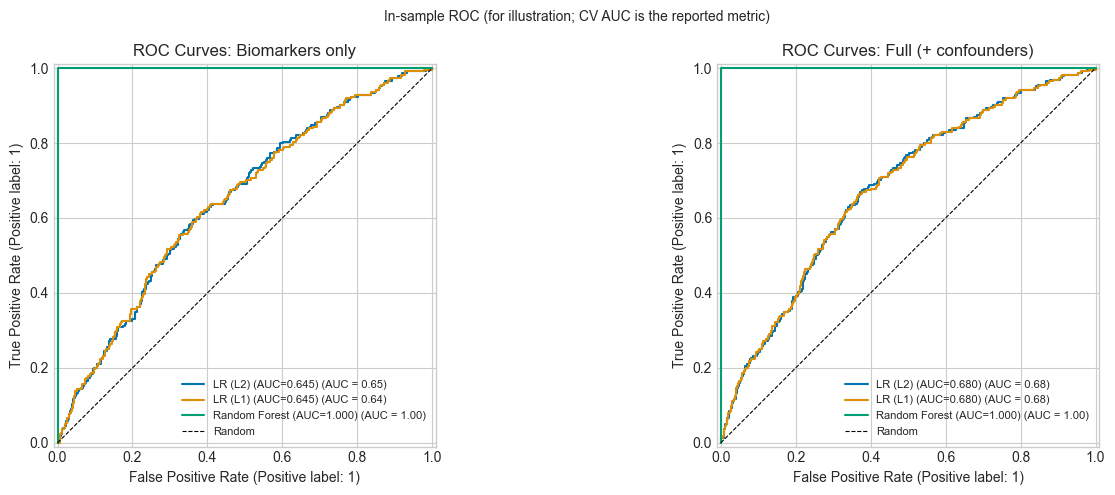

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat_name, X) in zip(axes, [('Biomarkers only', X_bio), ('Full (+ confounders)', X_full)]):
    for model_name, pipeline in models.items():
        pipeline.fit(X, y)
        y_prob = pipeline.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, y_prob)
        RocCurveDisplay.from_predictions(y, y_prob, ax=ax,
                                          name=f'{model_name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
    ax.set_title(f'ROC Curves: {feat_name}')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('In-sample ROC (for illustration; CV AUC is the reported metric)', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Permutation Feature Importance (Random Forest)

Permutation importance (drop in ROC-AUC) preferred over impurity-based for correlated features.

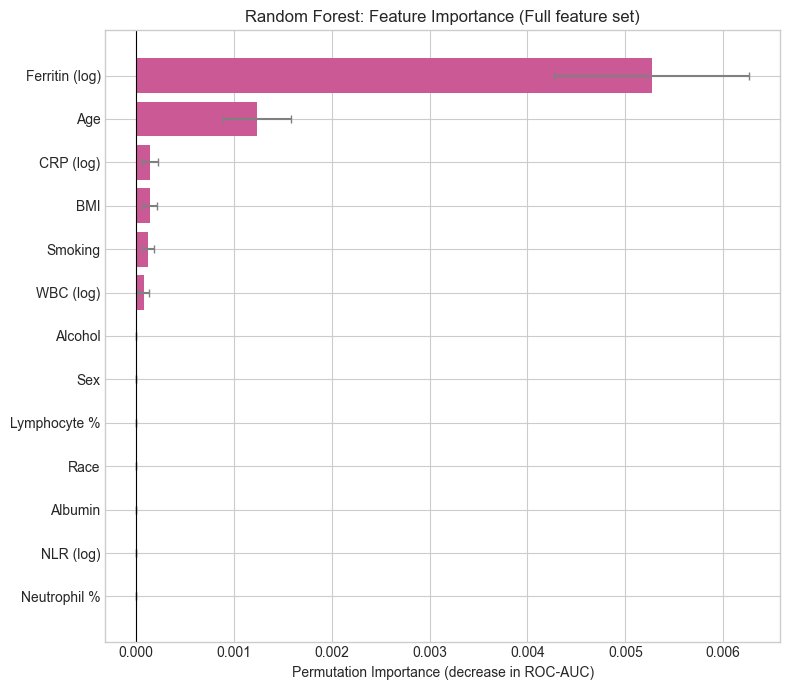

In [5]:
rf_pipeline = models['Random Forest']
rf_pipeline.fit(X_full, y)

perm = permutation_importance(rf_pipeline, X_full, y,
                               n_repeats=30, scoring='roc_auc',
                               n_jobs=-1, random_state=42)

imp_df = pd.DataFrame({
    'feature':    FULL_LABELS,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'], imp_df['importance'],
        xerr=imp_df['std'], color='#CA5995', ecolor='gray', capsize=3)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Permutation Importance (decrease in ROC-AUC)')
ax.set_title('Random Forest: Feature Importance (Full feature set)')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Logistic Regression Coefficients

Standardised coefficients from L2 LR (trained on full feature set) — directly comparable across features.

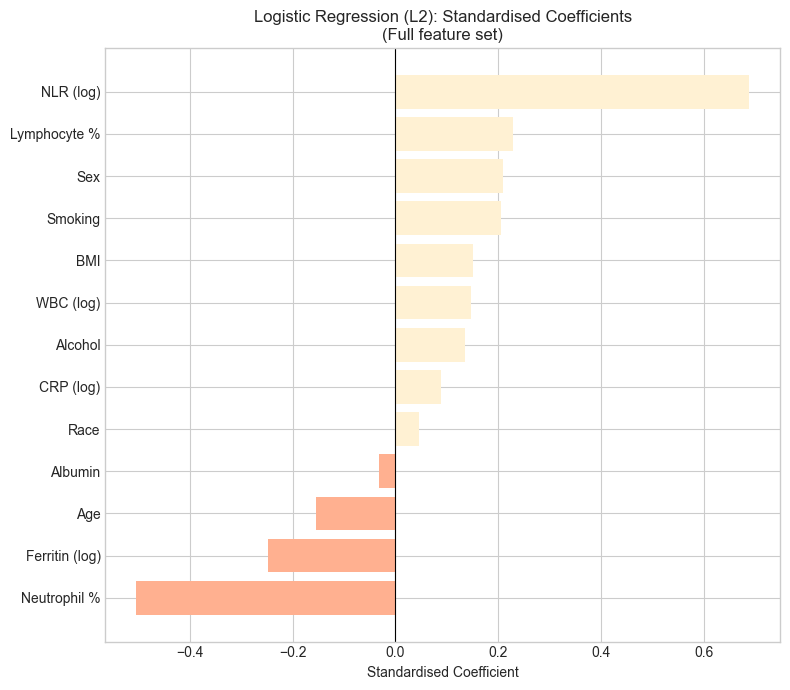

In [9]:
lr_pipeline = models['LR (L2)']
lr_pipeline.fit(X_full, y)
coefs = lr_pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': FULL_LABELS, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#FFF1D3' if c > 0 else '#FFB090' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Logistic Regression (L2): Standardised Coefficients\n(Full feature set)')
plt.tight_layout()
plt.savefig(FIGURES / 'lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-Symptom Prediction

Which PHQ-9 symptoms are most predictable from inflammatory markers alone?

Per-symptom AUC (inflammatory markers only, 10-fold CV):
  Anhedonia            AUC = 0.575
  Depressed mood       AUC = 0.584
  Sleep                AUC = 0.604
  Fatigue              AUC = 0.610
  Appetite             AUC = 0.603
  Self-worth           AUC = 0.594
  Concentration        AUC = 0.609
  Psychomotor          AUC = 0.562
  Suicidality          AUC = 0.511


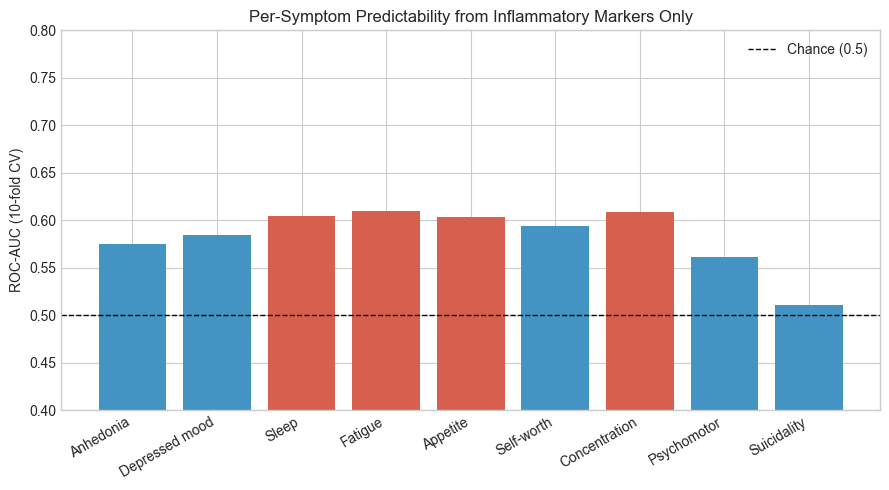

In [ ]:
y_multi = (df[PHQ_ITEMS] >= 2).astype(int).values

base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

print('Per-symptom AUC (inflammatory markers only, 10-fold CV):')
symptom_aucs = {}
for i, symptom in enumerate(ITEM_LABELS):
    result = cross_validate(base_lr, X_bio, y_multi[:, i],
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    mean_auc = result['test_score'].mean()
    symptom_aucs[symptom] = mean_auc
    print(f'  {symptom:<20} AUC = {mean_auc:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#CA5995' if a >= 0.6 else '#5D1C6A' for a in symptom_aucs.values()]
ax.bar(list(symptom_aucs.keys()), list(symptom_aucs.values()), color=colors)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Chance (0.5)')
ax.set_ylabel('ROC-AUC (10-fold CV)')
ax.set_title('Per-Symptom Predictability from Inflammatory Markers Only')
ax.set_ylim(0.4, 0.8)
plt.xticks(rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'per_symptom_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [8]:
print('=== Cross-Validation Performance Summary ===')
print(results_df.to_string())
print()
print('=== Most Predictable Symptoms (AUC >= 0.55) ===')
high_pred = {s: a for s, a in symptom_aucs.items() if a >= 0.55}
for s, a in sorted(high_pred.items(), key=lambda x: -x[1]):
    print(f'  {s:<20}: AUC = {a:.3f}')

=== Cross-Validation Performance Summary ===
                                     ROC-AUC (mean +/- sd) Avg Prec (mean +/- sd) Bal Acc (mean +/- sd)
LR (L2) | Biomarkers only                  0.623 +/- 0.040        0.220 +/- 0.044       0.604 +/- 0.037
LR (L2) | Full (+ confounders)             0.651 +/- 0.057        0.255 +/- 0.059       0.618 +/- 0.053
LR (L1) | Biomarkers only                  0.625 +/- 0.040        0.224 +/- 0.046       0.610 +/- 0.042
LR (L1) | Full (+ confounders)             0.650 +/- 0.058        0.254 +/- 0.060       0.613 +/- 0.051
Random Forest | Biomarkers only            0.573 +/- 0.056        0.181 +/- 0.046       0.498 +/- 0.002
Random Forest | Full (+ confounders)       0.592 +/- 0.056        0.195 +/- 0.038       0.500 +/- 0.000

=== Most Predictable Symptoms (AUC >= 0.55) ===
  Fatigue             : AUC = 0.610
  Concentration       : AUC = 0.609
  Sleep               : AUC = 0.604
  Appetite            : AUC = 0.603
  Self-worth          : AUC = 0.59